In [3]:
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted!


# Business Problem Definition

The HIGGS dataset is derived from Monte Carlo simulations used in particle physics experiments. The objective is to predict whether a collision event corresponds to the Higgs Boson signal (1) or background noise (0).

## Machine Learning Task

This is a Binary Classification problem.

Target Variable:
- Class = 1 → Higgs Boson signal event
- Class = 0 → Background event

## Business Objective

Particle physics experiments generate millions of collision events. Manual identification of Higgs events is computationally expensive and time consuming.

A machine learning model can automatically classify events and help researchers prioritize high-probability Higgs events for further analysis.

## Expected Output

The model predicts:
- 1 = Higgs signal
- 0 = Background event

The predictions can support faster scientific discovery and reduce computational costs.

# Dataset Description

Dataset Name: HIGGS Dataset

Source:
UCI Machine Learning Repository

Description:
The data was produced using Monte Carlo simulations.

Features:
- First 21 features are low-level kinematic properties measured by particle detectors.
- Last 7 features are high-level features engineered by physicists.

Target Variable:
Column 0

Dataset Size:
- Observations: 11,000,000
- Features: 28
- Target: 1 binary class variable



In [4]:
import os
os.getcwd()

'/content'

In [5]:
import os
print(os.listdir('/content/drive'))

['Shareddrives', 'MyDrive', '.shortcut-targets-by-id', '.Trash-0']


In [6]:
import os
os.listdir('/content/drive/Shareddrives')

[]

In [7]:
import os

for root, dirs, files in os.walk('/content/drive'):
    for file in files:
        if "Kinoo ka Project" in file.lower():
            print(os.path.join(root, file))

In [8]:
import os
os.listdir('/content/drive/.shortcut-targets-by-id')

['1UXilgJNqUOmo-27pw0eC1E1i2ed9Y0l_']

In [9]:
import pandas as pd


higgs = pd.read_csv('/content/drive/MyDrive/abc/KIRAN/HIGGS.csv')

In [10]:
higgs.head()

,1.000000000000000000e+00,8.692932128906250000e-01,-6.350818276405334473e-01,2.256902605295181274e-01,3.274700641632080078e-01,-6.899932026863098145e-01,7.542022466659545898e-01,-2.485731393098831177e-01,-1.092063903808593750e+00,0.000000000000000000e+00,...,-1.045456994324922562e-02,-4.576716944575309753e-02,3.101961374282836914e+00,1.353760004043579102e+00,9.795631170272827148e-01,9.780761599540710449e-01,9.200048446655273438e-01,7.216574549674987793e-01,9.887509346008300781e-01,8.766783475875854492e-01
0,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
1,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
2,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
3,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487
4,0.0,1.595839,-0.607811,0.007075,1.818450,-0.111906,0.847550,-0.566437,1.581239,2.173076,...,-0.654227,-1.274345,3.101961,0.823761,0.938191,0.971758,0.789176,0.430553,0.961357,0.957818


In [11]:
higgs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 29 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   1.000000000000000000e+00    float64
 1   8.692932128906250000e-01    float64
 2   -6.350818276405334473e-01   float64
 3   2.256902605295181274e-01    float64
 4   3.274700641632080078e-01    float64
 5   -6.899932026863098145e-01   float64
 6   7.542022466659545898e-01    float64
 7   -2.485731393098831177e-01   float64
 8   -1.092063903808593750e+00   float64
 9   0.000000000000000000e+00    float64
 10  1.374992132186889648e+00    float64
 11  -6.536741852760314941e-01   float64
 12  9.303491115570068359e-01    float64
 13  1.107436060905456543e+00    float64
 14  1.138904333114624023e+00    float64
 15  -1.578198313713073730e+00   float64
 16  -1.046985387802124023e+00   float64
 17  0.000000000000000000e+00.1  float64
 18  6.579295396804809570e-01    float64
 19  -1.0454569943249225

In [12]:
higgs.shape

(10999999, 29)

In [13]:

higgs.describe()

,1.000000000000000000e+00,8.692932128906250000e-01,-6.350818276405334473e-01,2.256902605295181274e-01,3.274700641632080078e-01,-6.899932026863098145e-01,7.542022466659545898e-01,-2.485731393098831177e-01,-1.092063903808593750e+00,0.000000000000000000e+00,...,-1.045456994324922562e-02,-4.576716944575309753e-02,3.101961374282836914e+00,1.353760004043579102e+00,9.795631170272827148e-01,9.780761599540710449e-01,9.200048446655273438e-01,7.216574549674987793e-01,9.887509346008300781e-01,8.766783475875854492e-01
count,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,...,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07,1.100000e+07
mean,5.299202e-01,9.914659e-01,-8.239884e-06,-1.329277e-05,9.985364e-01,2.619732e-05,9.909153e-01,-2.025261e-05,7.815478e-06,9.999688e-01,...,-5.756004e-06,1.745320e-05,1.000000e+00,1.034290e+00,1.024805e+00,1.050554e+00,1.009742e+00,9.729596e-01,1.033036e+00,9.598120e-01
std,4.991040e-01,5.653777e-01,1.008827e+00,1.006346e+00,6.000185e-01,1.006326e+00,4.749748e-01,1.009303e+00,1.005901e+00,1.027808e+00,...,1.007694e+00,1.006366e+00,1.400209e+00,6.746354e-01,3.808074e-01,1.645763e-01,3.974453e-01,5.254063e-01,3.652556e-01,3.133378e-01
min,0.000000e+00,2.746966e-01,-2.434976e+00,-1.742508e+00,2.370088e-04,-1.743944e+00,1.375024e-01,-2.969725e+00,-1.741237e+00,0.000000e+00,...,-2.497265e+00,-1.742691e+00,0.000000e+00,7.507046e-02,1.986757e-01,8.304866e-02,1.320062e-01,4.786215e-02,2.951122e-01,3.307214e-01
25%,0.000000e+00,5.907533e-01,-7.383225e-01,-8.719308e-01,5.768156e-01,-8.712081e-01,6.789927e-01,-6.872450e-01,-8.680962e-01,0.000000e+00,...,-7.141902e-01,-8.714789e-01,0.000000e+00,7.906095e-01,8.462266e-01,9.857525e-01,7.675732e-01,6.738168e-01,8.193964e-01,7.703901e-01
50%,1.000000e+00,8.533714e-01,-5.415563e-05,-2.410638e-04,8.916277e-01,2.125842e-04,8.948193e-01,-2.543566e-05,5.813991e-05,1.086538e+00,...,3.721330e-04,-2.642369e-04,0.000000e+00,8.949304e-01,9.506853e-01,9.897798e-01,9.165110e-01,8.733798e-01,9.473447e-01,8.719701e-01
75%,1.000000e+00,1.236226e+00,7.382142e-01,8.709940e-01,1.293056e+00,8.714708e-01,1.170740e+00,6.871941e-01,8.683126e-01,2.173076e+00,...,7.141017e-01,8.716055e-01,3.101961e+00,1.024730e+00,1.083493e+00,1.020528e+00,1.142226e+00,1.138439e+00,1.140458e+00,1.059248e+00
max,1.000000e+00,1.209891e+01,2.434868e+00,1.743236e+00,1.539682e+01,1.743257e+00,9.940391e+00,2.969674e+00,1.741454e+00,2.173076e+00,...,2.498009e+00,1.743372e+00,3.101961e+00,4.019237e+01,2.037278e+01,7.992739e+00,1.426244e+01,1.776285e+01,1.149652e+01,8.374498e+00


In [14]:
print(higgs.info())
print("\nShape:", higgs.shape)
print("\nData Types:\n", higgs.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 29 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   1.000000000000000000e+00    float64
 1   8.692932128906250000e-01    float64
 2   -6.350818276405334473e-01   float64
 3   2.256902605295181274e-01    float64
 4   3.274700641632080078e-01    float64
 5   -6.899932026863098145e-01   float64
 6   7.542022466659545898e-01    float64
 7   -2.485731393098831177e-01   float64
 8   -1.092063903808593750e+00   float64
 9   0.000000000000000000e+00    float64
 10  1.374992132186889648e+00    float64
 11  -6.536741852760314941e-01   float64
 12  9.303491115570068359e-01    float64
 13  1.107436060905456543e+00    float64
 14  1.138904333114624023e+00    float64
 15  -1.578198313713073730e+00   float64
 16  -1.046985387802124023e+00   float64
 17  0.000000000000000000e+00.1  float64
 18  6.579295396804809570e-01    float64
 19  -1.0454569943249225

In [15]:
higgs.isnull().sum()

,0
1.000000000000000000e+00,0
8.692932128906250000e-01,0
-6.350818276405334473e-01,0
2.256902605295181274e-01,0
3.274700641632080078e-01,0
-6.899932026863098145e-01,0
7.542022466659545898e-01,0
-2.485731393098831177e-01,0
-1.092063903808593750e+00,0
0.000000000000000000e+00,0


In [16]:
columns = ['target']

for i in range(1,29):
    columns.append(f'feature_{i}')

higgs.columns = columns

higgs.head()

,target,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28
0,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
1,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
2,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
3,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487
4,0.0,1.595839,-0.607811,0.007075,1.818450,-0.111906,0.847550,-0.566437,1.581239,2.173076,...,-0.654227,-1.274345,3.101961,0.823761,0.938191,0.971758,0.789176,0.430553,0.961357,0.957818


In [17]:
# Missing values count

missing_values = higgs.isnull().sum()

missing_values[missing_values > 0]

,0


In [18]:
# Total missing values

print("Total Missing Values:", higgs.isnull().sum().sum())

Total Missing Values: 0


In [19]:
duplicates = higgs.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 278698


In [20]:
# Remove duplicates if needed

higgs = higgs.drop_duplicates()

print(higgs.shape)

(10721301, 29)


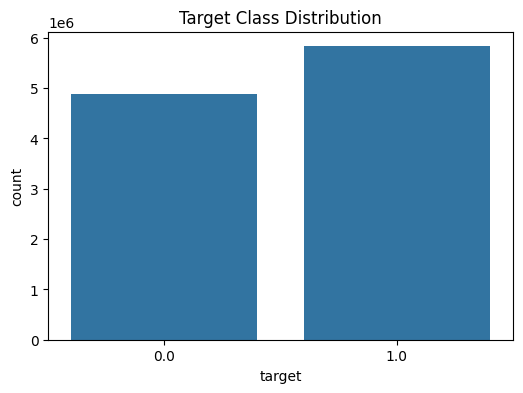

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=higgs)

plt.title("Target Class Distribution")
plt.show()

In [22]:
higgs['target'].value_counts(normalize=True)*100

,proportion
target,
1.0,54.36954
0.0,45.63046


# Feature Distribution Analysis

Understanding the distribution of variables is an important part of exploratory data analysis.

Feature distributions help identify:

- Data spread
- Skewness
- Variability
- Potential anomalies

Since the HIGGS dataset contains millions of observations, a random sample is used for visualization purposes.

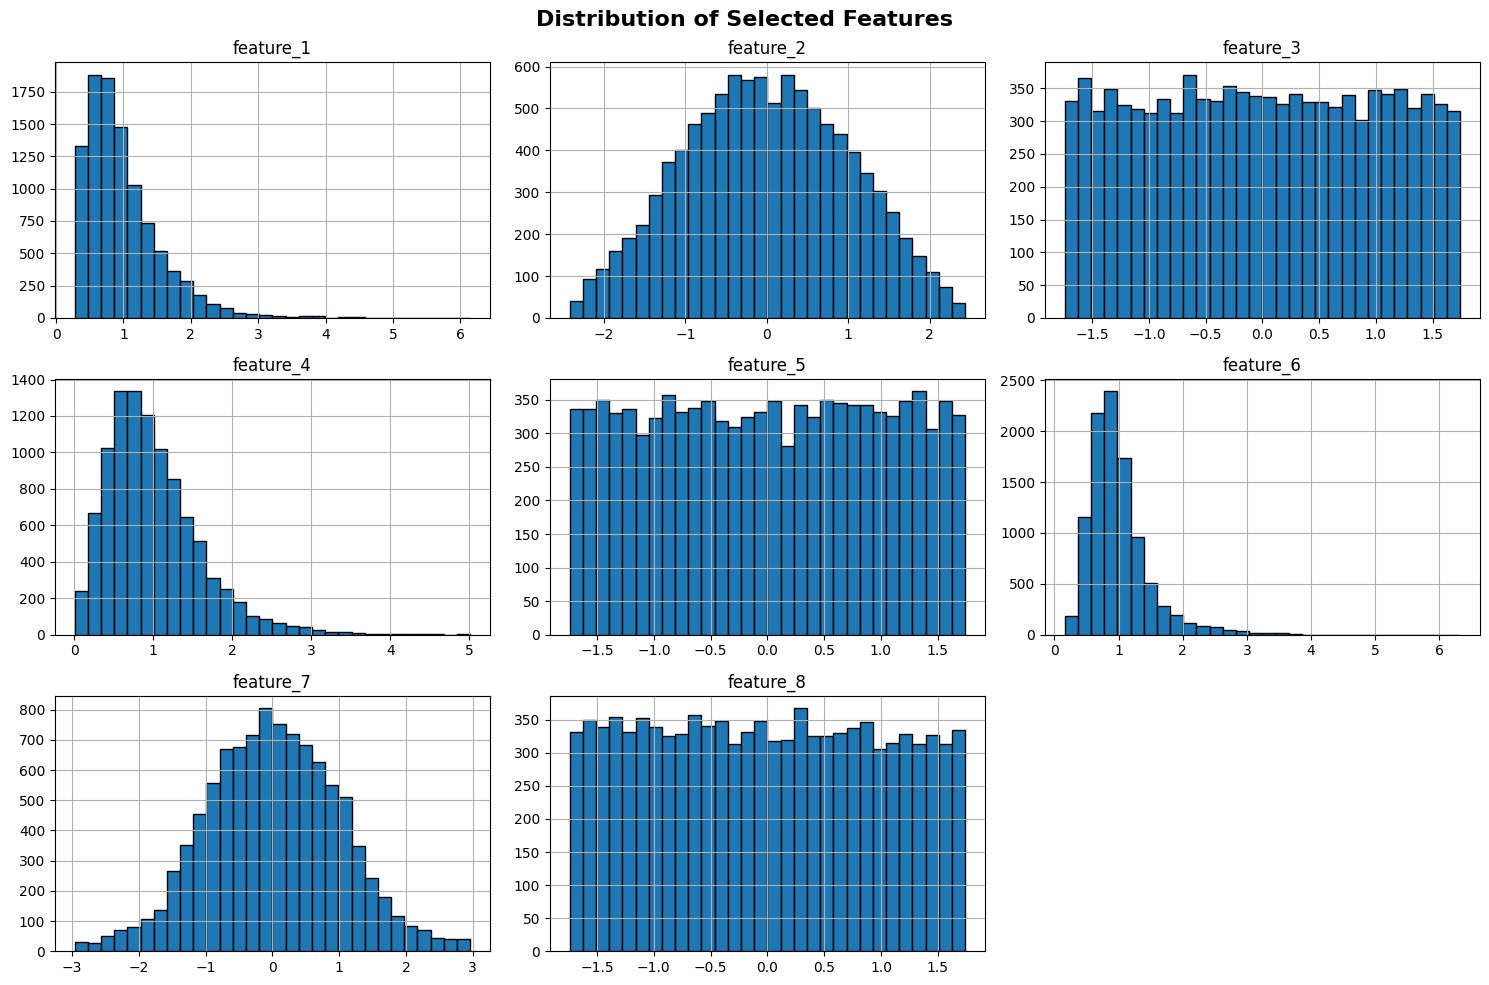

In [23]:
distribution_sample = higgs.sample(
    n=10000,
    random_state=42
)

distribution_sample.iloc[:,1:9].hist(
    bins=30,
    figsize=(15,10),
    edgecolor='black'
)

plt.suptitle(
    "Distribution of Selected Features",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

### Interpretation

The selected features show varying distributions and ranges.

Some variables appear approximately symmetric, while others display skewness and wider variability.

These differences suggest that feature scaling will be beneficial before training machine learning models.

# Outlier Analysis

Boxplots are used to identify extreme observations and examine the spread of numerical features.

Outliers may influence model performance and should be investigated before model training.

In [24]:
# Summary statistics for identifying potential outliers

higgs.describe().T[['min', '25%', '50%', '75%', 'max']]

,min,25%,50%,75%,max
target,0.000000,0.000000,1.000000,1.000000,1.000000
feature_1,0.274697,0.590936,0.853188,1.234945,12.098914
feature_2,-2.434976,-0.738322,-0.000054,0.738214,2.434868
feature_3,-1.742508,-0.871931,-0.000241,0.870994,1.743236
feature_4,0.000237,0.576348,0.890535,1.290940,15.396821
feature_5,-1.743944,-0.871191,0.000198,0.871532,1.743257
feature_6,0.137502,0.679726,0.895552,1.171290,9.940391
feature_7,-2.969725,-0.687245,-0.000025,0.687194,2.969674
feature_8,-1.741237,-0.868096,0.000161,0.868313,1.741454
feature_9,0.000000,0.000000,1.086538,2.173076,2.173076


# Feature Relationship with Target Variable

To understand the predictive power of individual variables, selected features are compared across the two target classes.

The analysis helps determine whether the distributions of signal events and background events differ.

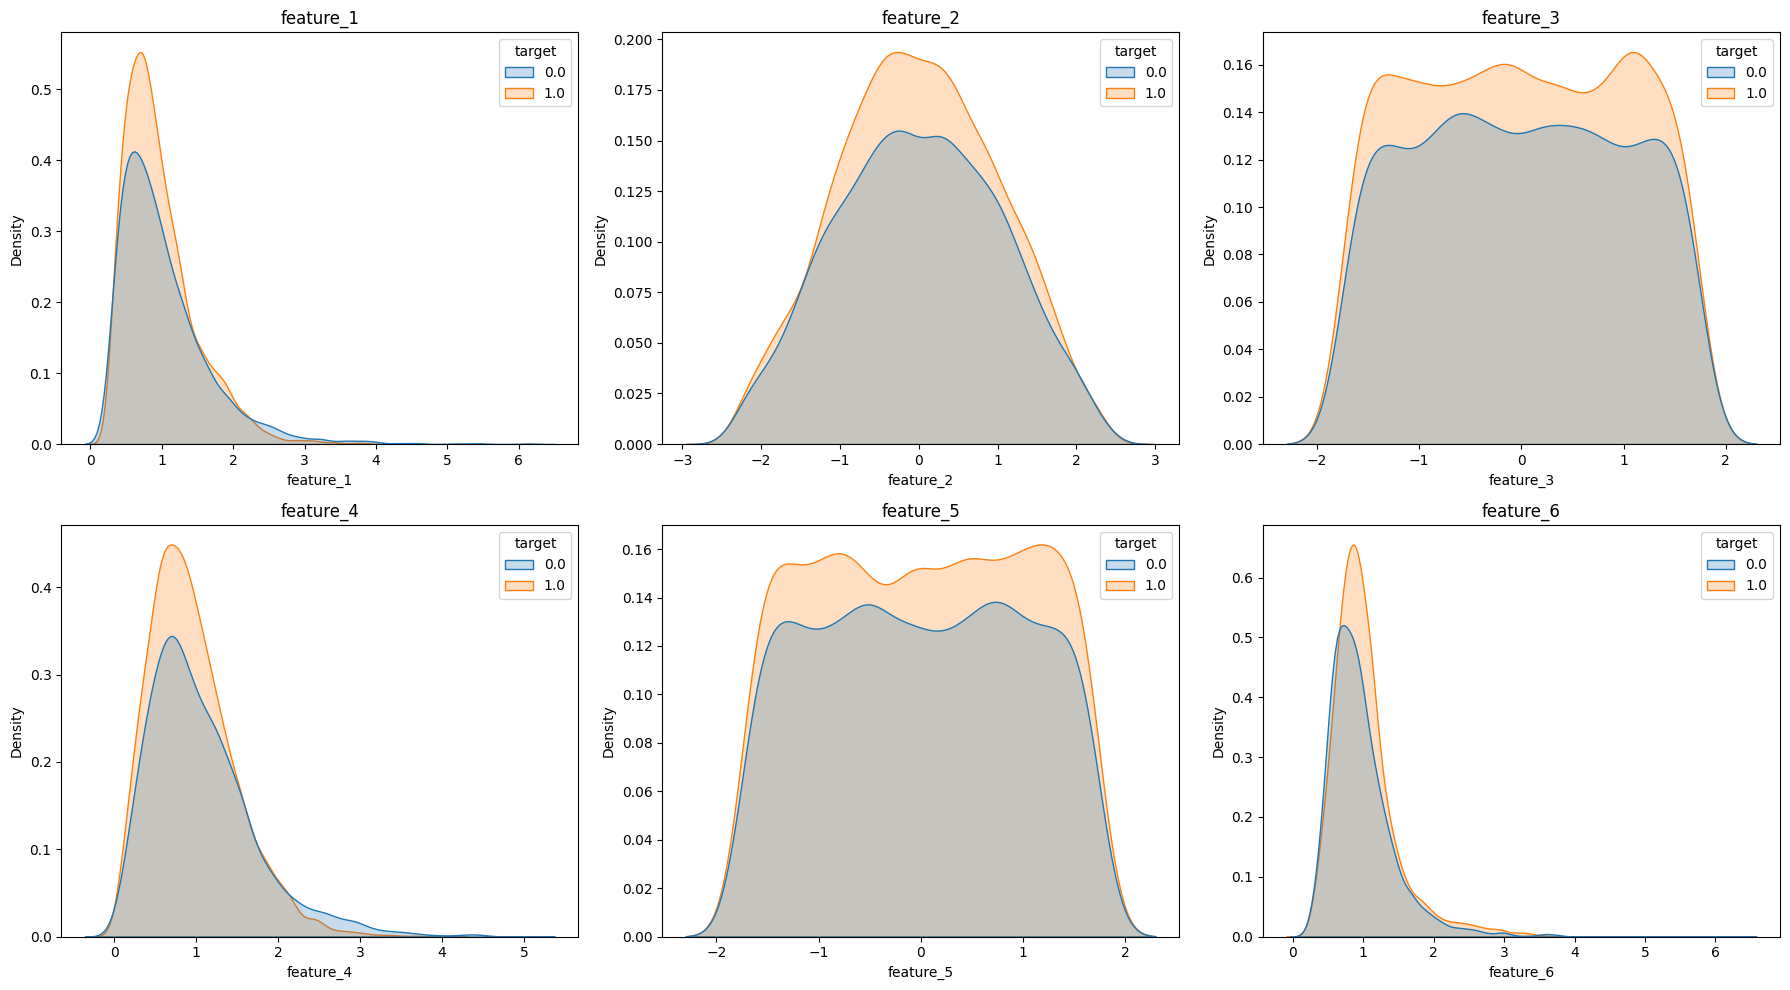

In [25]:
analysis_sample = higgs.sample(
    n=10000,
    random_state=42
)

selected_features = higgs.columns[1:7]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

for feature, ax in zip(selected_features, axes.flatten()):

    sns.kdeplot(
        data=analysis_sample,
        x=feature,
        hue='target',
        fill=True,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

In [26]:
# Summary statistics for identifying potential outliers

higgs.describe().T[['min', '25%', '50%', '75%', 'max']]

,min,25%,50%,75%,max
target,0.000000,0.000000,1.000000,1.000000,1.000000
feature_1,0.274697,0.590936,0.853188,1.234945,12.098914
feature_2,-2.434976,-0.738322,-0.000054,0.738214,2.434868
feature_3,-1.742508,-0.871931,-0.000241,0.870994,1.743236
feature_4,0.000237,0.576348,0.890535,1.290940,15.396821
feature_5,-1.743944,-0.871191,0.000198,0.871532,1.743257
feature_6,0.137502,0.679726,0.895552,1.171290,9.940391
feature_7,-2.969725,-0.687245,-0.000025,0.687194,2.969674
feature_8,-1.741237,-0.868096,0.000161,0.868313,1.741454
feature_9,0.000000,0.000000,1.086538,2.173076,2.173076


# Data Preparation

After completing exploratory data analysis, the dataset is prepared for machine learning.

The following preprocessing steps are performed:

1. Separate predictor variables and target variable
2. Create a representative sample
3. Split the data into training and testing sets
4. Standardize feature values

These steps ensure that the data is suitable for model training and evaluation.

In [27]:
# Separate features and target

X = higgs.drop('target', axis=1)

y = higgs['target']

# Sampling Strategy

The original HIGGS dataset contains more than 11 million observations.

Training multiple machine learning models on the complete dataset would require substantial computational resources and execution time.

Therefore, a random sample of 500,000 observations is selected while preserving the overall data distribution.

In [28]:
higgs_sample = higgs.sample(
    n=500000,
    random_state=42
)

X = higgs_sample.drop('target', axis=1)

y = higgs_sample['target']

# Train-Test Split

The dataset is divided into training and testing subsets.

- Training Set: 80%
- Testing Set: 20%

The testing dataset remains unseen during training and is used to evaluate model performance on new observations.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature Scaling

Many machine learning algorithms perform better when variables are measured on a similar scale.

StandardScaler is used to standardize the predictor variables by transforming them to a mean of zero and a standard deviation of one.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Model Building

Four machine learning algorithms are selected for comparison:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

These algorithms represent different learning approaches and provide a comprehensive evaluation of classification performance.

## Logistic Regression

Logistic Regression is a widely used classification algorithm that serves as a strong baseline model.

It is computationally efficient and provides interpretable results.

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

## Decision Tree

Decision Trees classify observations by learning a sequence of decision rules from the training data.

They can capture complex non-linear relationships but may overfit the training data.

In [32]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## Random Forest

Random Forest combines multiple decision trees and aggregates their predictions.

This ensemble approach generally improves predictive performance and reduces overfitting.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## XGBoost

XGBoost is a gradient boosting algorithm that builds trees sequentially and focuses on correcting previous prediction errors.

It is widely regarded as one of the strongest algorithms for structured tabular data.

In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# Model Evaluation

The models are evaluated using four classification metrics:

- Accuracy
- Precision
- Recall
- F1 Score

Using multiple metrics provides a more comprehensive assessment than relying solely on accuracy.

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(name, y_true, y_pred):

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

In [36]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results_df = pd.DataFrame(results)

results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.73703,0.750677,0.774102,0.762210
2,Random Forest,0.73084,0.745116,0.768519,0.756637
0,Logistic Regression,0.64584,0.645297,0.776123,0.704689
1,Decision Tree,0.63973,0.669895,0.666930,0.668409


# Model Comparison

To better understand model performance, all models are compared using their F1-Scores.

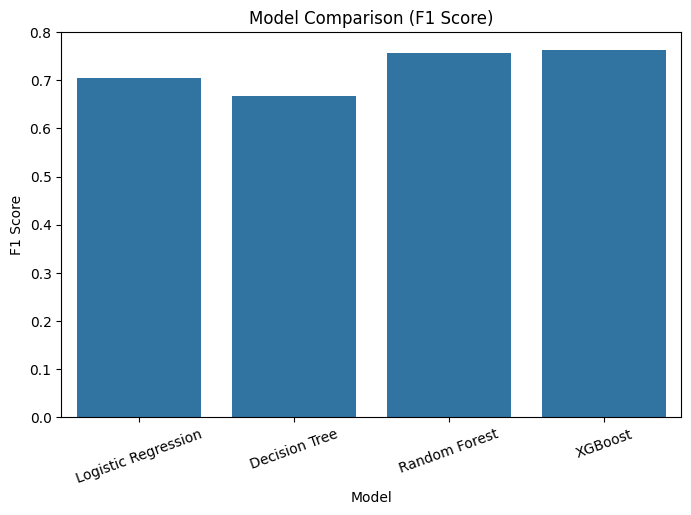

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1 Score'
)

plt.xticks(rotation=20)

plt.title("Model Comparison (F1 Score)")
plt.show()

# Best Model Selection

The best performing model is selected based on the highest F1-score.

In [38]:
best_model = results_df.sort_values(by='F1 Score', ascending=False).iloc[0]

best_model

,3
Model,XGBoost
Accuracy,0.73703
Precision,0.750677
Recall,0.774102
F1 Score,0.76221


# Confusion Matrix

Confusion matrix shows correct and incorrect predictions of the best model.

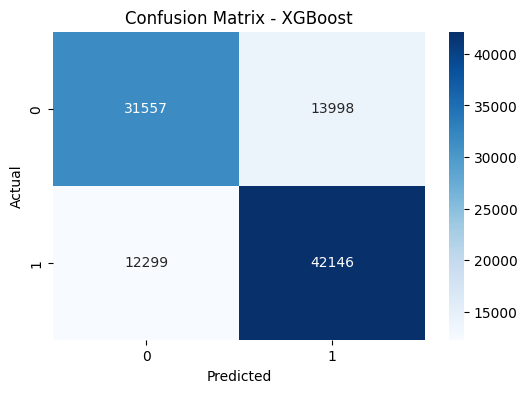

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# Hyperparameter Tuning

The best performing model (XGBoost) is optimized using Randomized Search to improve performance.

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=5,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

search.best_params_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}

# Tuned Model Evaluation

In [41]:
best_model = search.best_estimator_

tuned_pred = best_model.predict(X_test)

In [42]:
from sklearn.metrics import f1_score

print("Before Tuning:", f1_score(y_test, xgb_pred))
print("After Tuning :", f1_score(y_test, tuned_pred))

Before Tuning: 0.7622096230185642
After Tuning : 0.75732421875


# Feature Importance

Feature importance shows which variables contribute most to prediction.

In [43]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False).head(10)

importance

,Feature,Importance
25,feature_26,0.187033
27,feature_28,0.096370
26,feature_27,0.095611
22,feature_23,0.080137
24,feature_25,0.072686
5,feature_6,0.071059
3,feature_4,0.041865
8,feature_9,0.039842
21,feature_22,0.036902
0,feature_1,0.034117


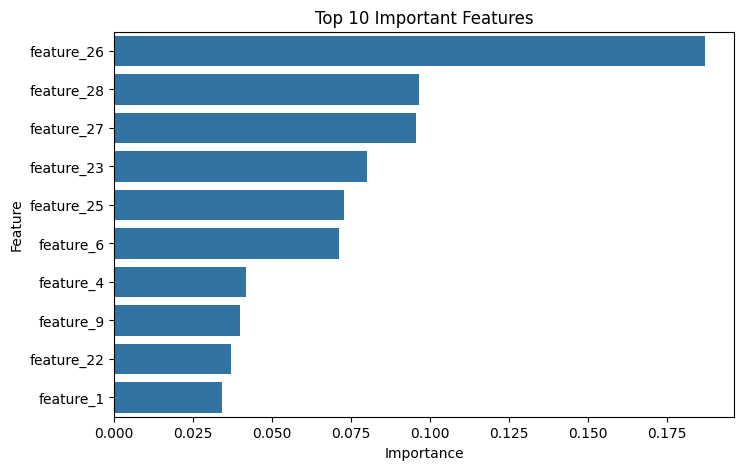

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

# Business Interpretation

The final model (XGBoost) achieved the best performance among all tested algorithms.

### Key Insights:
- The model can effectively distinguish Higgs signal from background events.
- High recall ensures fewer missed signal events.
- High precision reduces unnecessary further analysis.

### Business/Scientific Impact:
- Reduces manual analysis workload for physicists.
- Speeds up discovery of important particle events.
- Improves efficiency of particle collision analysis systems.

### Risks:
- Model depends on simulated data; real-world performance may vary.
- Potential overfitting if tuning is not controlled.